# Anotador TDAH · 05 · Comparación de experimentos

Comparación d elos experimentos con la tabla `experimento` y compara los experimentos guardados por los cuadernos 01–04 usando sus códigos.


## 1 · Parámetros

In [17]:
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

RUTA_BD = "datos/anotador.db"
CODIGOS = None   # None = todos los experimentos; o lista de códigos:
                 # ["directo-s1-t0.7-20260712", "langchain-s1-t0.7-20260712"]

con = sqlite3.connect(RUTA_BD)

## 2 · Experimentos disponibles

In [18]:
df = pd.read_sql("SELECT * FROM experimento", con)

catalogo = (
    df.groupby("codigo")
    .agg(
        backend=("backend", "first"),
        modelo=("modelo", "first"),
        temperatura=("temperatura", "first"),
        semana=("semana", "first"),
        anotaciones=("id", "count"),
        primera=("creada_en", "min"),
    )
    .sort_values("primera")
    .reset_index()
)
catalogo.insert(0, "i", range(len(catalogo)))  

print(f"{len(df)} anotaciones de {len(catalogo)} experimentos\n")
catalogo.set_index("i") 

360 anotaciones de 4 experimentos



,codigo,backend,modelo,temperatura,semana,anotaciones,primera
i,,,,,,,
0,directo-s1-t0.7-20260713,directo,gemma4:e4b,0.7,1,90,2026-07-13T08:54:32
1,langchain-s1-t0.7-20260713,langchain,gemma4:e4b,0.7,1,90,2026-07-13T11:54:31
2,tool_calling-s1-t0.7-20260713,tool_calling,gemma4:e4b,0.7,1,90,2026-07-13T14:00:35
3,instructor-s1-t0.7-20260713,instructor,gemma4:e4b,0.7,1,90,2026-07-13T14:42:03


## 2b · Elegir experimentos a comparar

In [19]:
SELECCION = [0, 1, 2, 3]   # índices i de la tabla de arriba
CODIGOS = None

if CODIGOS:
    elegidos = list(CODIGOS)
else:
    elegidos = catalogo.loc[SELECCION, "codigo"].tolist()

df = df[df["codigo"].isin(elegidos)].copy()

print(f"Comparando {len(elegidos)} experimento(s) · {len(df)} anotaciones:\n")
for c in elegidos:
    n = (df["codigo"] == c).sum()
    b = catalogo.loc[catalogo["codigo"] == c, "backend"].iloc[0]
    print(f"  [{b:16}] {c}  ({n} filas)")

Comparando 4 experimento(s) · 360 anotaciones:

  [directo         ] directo-s1-t0.7-20260713  (90 filas)
  [langchain       ] langchain-s1-t0.7-20260713  (90 filas)
  [tool_calling    ] tool_calling-s1-t0.7-20260713  (90 filas)
  [instructor      ] instructor-s1-t0.7-20260713  (90 filas)


## 3 · Tabla comparativa

Una fila por experimento:

- `formato_ok`: fracción de anotaciones con JSON válido (por repetición).
- `pct_formato_3`, `pct_nivel_3`, `pct_items_3`, `pct_escalas_3`: % de pacientes que cumplen cada criterio en las 3 repeticiones.
Columna	Criterio
pct_formato_3 si formato_ok = 1 en las 3 repeticiones
pct_nivel_3 si mismo nivel_alerta en las 3
pct_items_3 si  mismos items_detectados en las 3
pct_escalas_3 si mismas escalas_afectadas en las 3
pct_estable si cumple las 4 (si falla alguna → inestable)
- `pct_estable`: % de pacientes que cumplen **todas** las condiciones (si falla alguna → inestable).
- `acuerdo_nivel`: media del acuerdo gradual del `nivel_alerta` (como antes; 1.0 = las 3 iguales).
- `latencia_media`: segundos por anotación.

In [20]:
def acuerdo_modal(niveles):
    """Fracción de repeticiones que coincide con el nivel más frecuente."""
    s = niveles.dropna()
    return s.value_counts().iloc[0] / len(s) if len(s) else None


def _parse_json(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return None
    return json.loads(val) if isinstance(val, str) else val


def metricas_paciente(g):
    """Por paciente: cumple cada criterio en las 3 repeticiones y si es estable."""
    g = g.sort_values("repeticion")
    ok_formato_3 = g["formato_ok"].min() == 1
    ok_nivel_3 = g["nivel_alerta"].nunique() == 1
    items = g["items_detectados"].map(_parse_json).astype(str)
    escalas = g["escalas_afectadas"].map(_parse_json).astype(str)
    ok_items_3 = items.nunique() == 1
    ok_escalas_3 = escalas.nunique() == 1
    return pd.Series({
        "id_entrada": int(g["id_entrada"].iloc[0]),
        "formato_3": ok_formato_3,
        "nivel_3": ok_nivel_3,
        "items_3": ok_items_3,
        "escalas_3": ok_escalas_3,
        "estable": ok_formato_3 and ok_nivel_3 and ok_items_3 and ok_escalas_3,
        "acuerdo_nivel": acuerdo_modal(g["nivel_alerta"]),
    })


por_paciente = (
    df.groupby(["codigo", "id_paciente"], group_keys=False)
    .apply(metricas_paciente)
)

estabilidad = por_paciente.groupby("codigo").agg(
    pct_formato_3=("formato_3", "mean"),
    pct_nivel_3=("nivel_3", "mean"),
    pct_items_3=("items_3", "mean"),
    pct_escalas_3=("escalas_3", "mean"),
    pct_estable=("estable", "mean"),
    acuerdo_nivel=("acuerdo_nivel", "mean"),
)

comparativa = (
    df.groupby("codigo")
    .agg(
        backend=("backend", "first"),
        temperatura=("temperatura", "first"),
        semana=("semana", "first"),
        formato_ok=("formato_ok", "mean"),
        latencia_media=("latencia_s", "mean"),
    )
    .join(estabilidad)
    .sort_values("pct_estable", ascending=False)
    .round(2)
)
comparativa

,backend,temperatura,semana,formato_ok,latencia_media,pct_formato_3,pct_nivel_3,pct_items_3,pct_escalas_3,pct_estable,acuerdo_nivel
codigo,,,,,,,,,,,
langchain-s1-t0.7-20260713,langchain,0.7,1,1.00,8.73,1.00,0.83,0.60,0.77,0.57,0.94
instructor-s1-t0.7-20260713,instructor,0.7,1,1.00,9.11,1.00,0.57,0.57,0.53,0.37,0.86
directo-s1-t0.7-20260713,directo,0.7,1,0.97,8.66,0.90,0.70,0.57,0.50,0.33,0.88
tool_calling-s1-t0.7-20260713,tool_calling,0.7,1,0.99,2.31,0.97,0.80,0.47,0.30,0.17,0.93


## 4 · Gráfico: estabilidad frente a coste

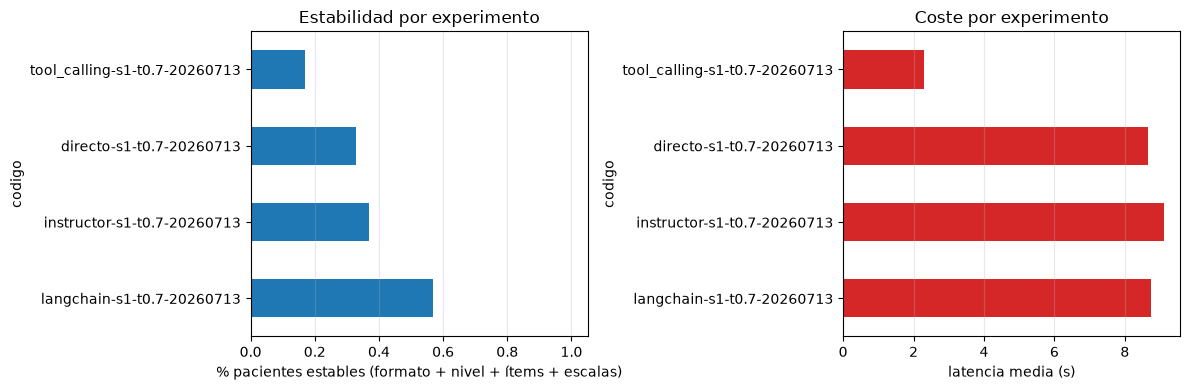

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

comparativa["pct_estable"].plot.barh(ax=ax[0], color="tab:blue")
ax[0].set_xlim(0, 1.05)
ax[0].set_xlabel("% pacientes estables (formato + nivel + ítems + escalas)")
ax[0].set_title("Estabilidad por experimento")
ax[0].grid(alpha=0.3, axis="x")

comparativa["latencia_media"].plot.barh(ax=ax[1], color="tab:red")
ax[1].set_xlabel("latencia media (s)")
ax[1].set_title("Coste por experimento")
ax[1].grid(alpha=0.3, axis="x")

plt.tight_layout(); plt.show()

## 5 · Detalle por paciente (rep0 | rep1 | rep2)

Para un experimento concreto:

- **Cabecera visible** por paciente: estable / inestable, ID y fallos (si los hay).
- **Desplegable** solo para la tabla ancha `rep0 | rep1 | rep2` (inestables abiertos por defecto).

In [24]:
from IPython.display import HTML, display

# Índice en catalogo / lista de experimentos elegidos (0, 1, 2, 3...)
IDX_EXPERIMENTO = 0
UN_EXPERIMENTO = df["codigo"].drop_duplicates().tolist()[IDX_EXPERIMENTO]

CAMPOS = [
    ("formato_ok", "formato_ok"),
    ("nivel_alerta", "nivel_alerta"),
    ("items_detectados", "items_detectados"),
    ("escalas_afectadas", "escalas_afectadas"),
    ("nota_clinica", "nota_clinica"),
    ("justificacion", "justificacion"),
    ("latencia_s", "latencia_s"),
]
MAX_TEXTO = 160  


def _fmt(val, campo):
    if campo in ("items_detectados", "escalas_afectadas"):
        val = _parse_json(val)
    if isinstance(val, float) and campo == "latencia_s":
        return round(val, 2)
    texto = str(val) if val is not None else ""
    if campo in ("nota_clinica", "justificacion") and len(texto) > MAX_TEXTO:
        return texto[:MAX_TEXTO] + "…"
    return val


def tabla_ancha(g):
    g = g.sort_values("repeticion")
    filas = []
    for col, etiqueta in CAMPOS:
        fila = {"campo": etiqueta}
        for _, r in g.iterrows():
            fila[f"rep{int(r['repeticion'])}"] = _fmt(r[col], col)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("campo")


def _fallos(row):
    motivos = []
    if not row["formato_3"]:
        motivos.append("formato")
    if not row["nivel_3"]:
        motivos.append("nivel")
    if not row["items_3"]:
        motivos.append("ítems")
    if not row["escalas_3"]:
        motivos.append("escalas")
    return ", ".join(motivos)


d = df[df["codigo"] == UN_EXPERIMENTO].copy()
resumen_df = (
    por_paciente.loc[UN_EXPERIMENTO]
    .reset_index()
    .sort_values(["estable", "acuerdo_nivel", "id_paciente"], ascending=[True, True, True])
)

print(f"Experimento: {UN_EXPERIMENTO}")
print(
    f"Estables: {resumen_df['estable'].sum()} · "
    f"Inestables: {(~resumen_df['estable']).sum()} de {len(resumen_df)} pacientes\n"
)

bloques = [
    """<style>
.detalle-paciente { margin: 10px 0; border: 1px solid #ccc; border-radius: 4px; overflow: hidden; }
.detalle-paciente .cabecera {
    padding: 8px 12px; font-weight: 600; color: #1e1e1e;
    border-bottom: 1px solid #ddd;
}
.detalle-paciente.inestable .cabecera { background: #ffe6e6; }
.detalle-paciente.estable .cabecera { background: #eef6ee; }
.detalle-paciente summary {
    padding: 6px 12px; cursor: pointer; color: #1e1e1e;
    background: #f7f7f7;
}
.detalle-paciente .detalle-rep { margin: 0; }
</style>"""
]

for _, row in resumen_df.iterrows():
    paciente = row["id_paciente"]
    g = d[d["id_paciente"] == paciente]
    clase = "inestable" if not row["estable"] else "estable"
    etiqueta = "INESTABLE" if not row["estable"] else "estable"
    titulo = f"{etiqueta} · {paciente} · entrada {int(row['id_entrada'])}"
    if not row["estable"]:
        titulo += f" · fallos: {_fallos(row)}"
    abierto = " open" if not row["estable"] else ""
    tabla = tabla_ancha(g).to_html(classes="detalle-rep", border=0)
    bloques.append(
        f"<div class='detalle-paciente {clase}'>"
        f"<div class='cabecera'>{titulo}</div>"
        f"<details{abierto}><summary>Ver rep0 | rep1 | rep2</summary>{tabla}</details>"
        f"</div>"
    )

display(HTML("\n".join(bloques)))

Experimento: directo-s1-t0.7-20260713
Estables: 10 · Inestables: 20 de 30 pacientes



,rep0,rep1,rep2
campo,,,
formato_ok,1,1,1
nivel_alerta,moderado,bajo,alto
items_detectados,[],[],[]
escalas_afectadas,"[control_emocional, flexibilidad]","[flexibilidad, control_emocional]","[control_emocional, flexibilidad]"
nota_clinica,"El paciente se encuentra en un contexto de alta vulnerabilidad emocional debido a la victimización por parte de sus compañeros, quienes utilizan apodos vinculad…",El texto describe una situación de estrés psicosocial (bullying y crítica social) más que déficits ejecutivos primarios. La vulnerabilidad emocional ante la crí…,"El paciente se encuentra actualmente en un contexto de alto estrés psicosocial debido al acoso y la burla por parte de sus compañeros, lo cual afecta gravemente…"
justificacion,"El texto no proporciona observaciones directas sobre habilidades ejecutivas (planificación, organización, memoria de trabajo) ni descripciones detalladas de con…","El texto no contiene observaciones funcionales directas del comportamiento diario del paciente (ej. desorden, impulsividad, olvidos) para asignar ítems específi…","El texto no proporciona observaciones específicas sobre déficits funcionales (ej. desorganización, impulsividad o dificultades de memoria de trabajo) que puedan…"
latencia_s,8.59,9.16,7.37
,rep0,rep1,rep2
campo,,,
